<a href="https://colab.research.google.com/github/Edith123321/hidden-markov-formative/blob/main/HMM_Activity_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modeling Human Activity States Using Hidden Markov Models
**Formative 2 — Group Assignment**

| | |
|---|---|
| **Edith Githinji** | iPhone 13  @ 100 Hz |
| **Liliane Gikundiro** |  iPhone 13 @ 100 Hz |

**Activities:** Still · Standing · Walking · Jumping

**Sampling rate:** 100 Hz (harmonised between both devices)

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
"""
=============================================================================
 Modeling Human Activity States Using Hidden Markov Models
 Group Assignment – Formative 2
=============================================================================
 Authors   : Edith Githinji
             Liliane Gikundiro
 Phones    : Edith – iPhone 13   @ 100 Hz
             Liliane – Samsung S22    @ 100 Hz (harmonised to 100 Hz)
 Activities: Still | Standing | Walking | Jumping
=============================================================================
"""


'\n=============================================================================\n Modeling Human Activity States Using Hidden Markov Models\n Group Assignment – Formative 2\n=============================================================================\n Authors   : Edith Githinji\n             Liliane Gikundiro\n Phones    : Edith – iPhone 13   @ 100 Hz\n             Liliane – Samsung S22    @ 100 Hz (harmonised to 100 Hz)\n Activities: Still | Standing | Walking | Jumping\n=============================================================================\n'

## 1. Imports & Configuration

In [ ]:
import os, warnings, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import signal as sp_signal
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Paths (Drive is already mounted in Cell 0) ─────────────────────────────
FIG_DIR = pathlib.Path("/content/figures")
FIG_DIR.mkdir(exist_ok=True)

# ── Constants ──────────────────────────────────────────────────────────────
ACTIVITIES      = ["still", "standing", "walking", "jumping"]
ACTIVITY_COLORS = {"still":"#3498db", "standing":"#2ecc71",
                   "walking":"#f39c12", "jumping":"#e74c3c"}
FS          = 100
WINDOW_SIZE = 50
STEP_SIZE   = 25

print("=" * 60)
print("  HMM Human Activity Recognition")
print("=" * 60)
print(f"  Sampling rate  : {FS} Hz")
print(f"  Window size    : {WINDOW_SIZE} samples ({WINDOW_SIZE/FS:.2f} s)")
print(f"  Step size      : {STEP_SIZE} samples ({STEP_SIZE/FS:.2f} s)")
print(f"  Activities     : {ACTIVITIES}")
print(f"  Figures dir    : {FIG_DIR}")

  HMM Human Activity Recognition
  Sampling rate  : 100 Hz
  Window size    : 50 samples (0.50 s)
  Step size      : 25 samples (0.25 s)
  Activities     : ['still', 'standing', 'walking', 'jumping']
  Figures dir    : /content/figures


## 2. Data Loading

In [ ]:
# ─── Cell 2: Load Data & Train/Test Split ──────────────────────────────────
import pathlib
import pandas as pd
from sklearn.model_selection import train_test_split

# --- Start of added code to address NameError: 'DATA_ROOT' not defined ---
DRIVE_PROJECT_PATH = "MyDrive/data"   # <--- IMPORTANT: Adjust this path if your data is elsewhere in Drive
DATA_ROOT = pathlib.Path("/content/drive") / DRIVE_PROJECT_PATH

# Sanity check
if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"Could not find: {DATA_ROOT}\n"
        f"Check that DRIVE_PROJECT_PATH is correct and Drive is mounted."
    )
print(f"  ✓ Data root found : {DATA_ROOT}")
# --- End of added code ---

# ── Load a single recording folder → DataFrame ────────────────────────────
def load_recording(folder: pathlib.Path):
    acc_path  = folder / "Accelerometer.csv"
    gyro_path = folder / "Gyroscope.csv"

    if not acc_path.exists() or not gyro_path.exists():
        print(f"  [skip] {folder.name:<25} (missing Accelerometer.csv or Gyroscope.csv)")
        return None

    acc  = pd.read_csv(acc_path).rename(columns={"x": "acc_x", "y": "acc_y", "z": "acc_z"})
    gyro = pd.read_csv(gyro_path).rename(columns={"x": "gyro_x", "y": "gyro_y", "z": "gyro_z"})

    acc  = acc.sort_values("time").reset_index(drop=True)
    gyro = gyro.sort_values("time").reset_index(drop=True)

    df = pd.merge_asof(
        acc,
        gyro[["time", "gyro_x", "gyro_y", "gyro_z"]],
        on="time",
        direction="nearest",
        tolerance=int(5e6)
    )
    df.dropna(subset=["gyro_x"], inplace=True)

    if df.empty:
        print(f"  [skip] {folder.name:<25} (merge produced 0 rows — check timestamps)")
        return None

    activity       = folder.name.split("_")[0]
    df["label"]    = activity
    df["filename"] = folder.name
    return df


# ── Discover all valid recording folders ──────────────────────────────────
all_subfolders = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir()])

recording_registry = []
for folder in all_subfolders:
    activity = folder.name.split("_")[0]
    if activity not in ACTIVITIES:
        print(f"  [skip] {folder.name:<25} ('{activity}' not in {ACTIVITIES})")
        continue
    recording_registry.append((folder, activity))

print(f"  Found {len(recording_registry)} valid recording folders:")
for act in ACTIVITIES:
    n = sum(1 for _, a in recording_registry if a == act)
    print(f"    {act:<12}: {n} recording(s)")


# ── Load everything into one DataFrame ────────────────────────────────────
print("\n  Loading all recordings...")
all_dfs = []
for folder, activity in recording_registry:
    df = load_recording(folder)
    if df is not None:
        all_dfs.append(df)
        secs = (df["time"].max() - df["time"].min()) / 1e9
        print(f"  Loaded {folder.name:<25} → {len(df):5d} rows  ({secs:.1f}s)  (label: {activity})")

if not all_dfs:
    raise FileNotFoundError(
        "No recordings loaded. Check that your folders contain "
        "Accelerometer.csv and Gyroscope.csv (capital A and G)."
    )

all_df = pd.concat(all_dfs, ignore_index=True)


# ── Folder-level stratified train/test split ──────────────────────────────
TEST_SIZE    = 0.2
RANDOM_STATE = 42

folders_all    = [f for f, _ in recording_registry]
activities_all = [a for _, a in recording_registry]

folders_train, folders_test, _, _ = train_test_split(
    folders_all,
    activities_all,
    test_size=TEST_SIZE,
    stratify=activities_all,
    random_state=RANDOM_STATE
)

train_names = {f.name for f in folders_train}
test_names  = {f.name for f in folders_test}

train_df = all_df[all_df["filename"].isin(train_names)].reset_index(drop=True)
test_df  = all_df[all_df["filename"].isin(test_names)].reset_index(drop=True)


# ── Helper: seconds in a DataFrame ────────────────────────────────────────
def total_secs(df):
    return (df["time"].max() - df["time"].min()) / 1e9


# ── Summary ───────────────────────────────────────────────────────────────
print(f"\n{'─'*75}")
print(f"  {'Split':<8} {'Rows':>10}  {'Recordings':>12}  {'Seconds':>10}  {'Minutes':>10}")
print(f"{'─'*75}")
for label, df in [("All", all_df), ("Train", train_df), ("Test", test_df)]:
    secs = total_secs(df)
    print(f"  {label:<8} {len(df):>10,}  {df['filename'].nunique():>12}  {secs:>10.1f}  {secs/60:>10.2f}")
print(f"{'─'*75}")

print(f"\n  Train class distribution:")
print(f"  {'Activity':<12} {'Rows':>8}  {'Seconds':>9}  {'Minutes':>9}  {'Recordings':>12}")
print(f"  {'─'*56}")
for act in ACTIVITIES:
    sub  = train_df[train_df["label"] == act]
    secs = total_secs(sub)
    print(f"  {act:<12} {len(sub):>8,}  {secs:>9.1f}  {secs/60:>9.2f}  {sub['filename'].nunique():>12}")

print(f"\n  Test class distribution:")
print(f"  {'Activity':<12} {'Rows':>8}  {'Seconds':>9}  {'Minutes':>9}  {'Recordings':>12}")
print(f"  {'─'*56}")
for act in ACTIVITIES:
    sub  = test_df[test_df["label"] == act]
    secs = total_secs(sub)
    print(f"  {act:<12} {len(sub):>8,}  {secs:>9.1f}  {secs/60:>9.2f}  {sub['filename'].nunique():>12}")

  ✓ Data root found : /content/drive/MyDrive/data
  Found 50 valid recording folders:
    still       : 12 recording(s)
    standing    : 13 recording(s)
    walking     : 13 recording(s)
    jumping     : 12 recording(s)

  Loading all recordings...
  Loaded jumping_1                 →   784 rows  (7.9s)  (label: jumping)
  Loaded jumping_10                →   705 rows  (7.1s)  (label: jumping)
  Loaded jumping_11                →   745 rows  (7.5s)  (label: jumping)
  Loaded jumping_12                →   577 rows  (5.8s)  (label: jumping)
  Loaded jumping_2                 →   741 rows  (7.4s)  (label: jumping)
  Loaded jumping_3                 →   720 rows  (7.2s)  (label: jumping)
  Loaded jumping_4                 →   815 rows  (8.2s)  (label: jumping)
  Loaded jumping_5                 →   786 rows  (7.9s)  (label: jumping)
  Loaded jumping_6                 →   749 rows  (7.5s)  (label: jumping)
  Loaded jumping_7                 →   532 rows  (5.3s)  (label: jumping)
  Loaded 

## 3. Raw Data Visualisation


[Plot] Raw sensor signals per activity...


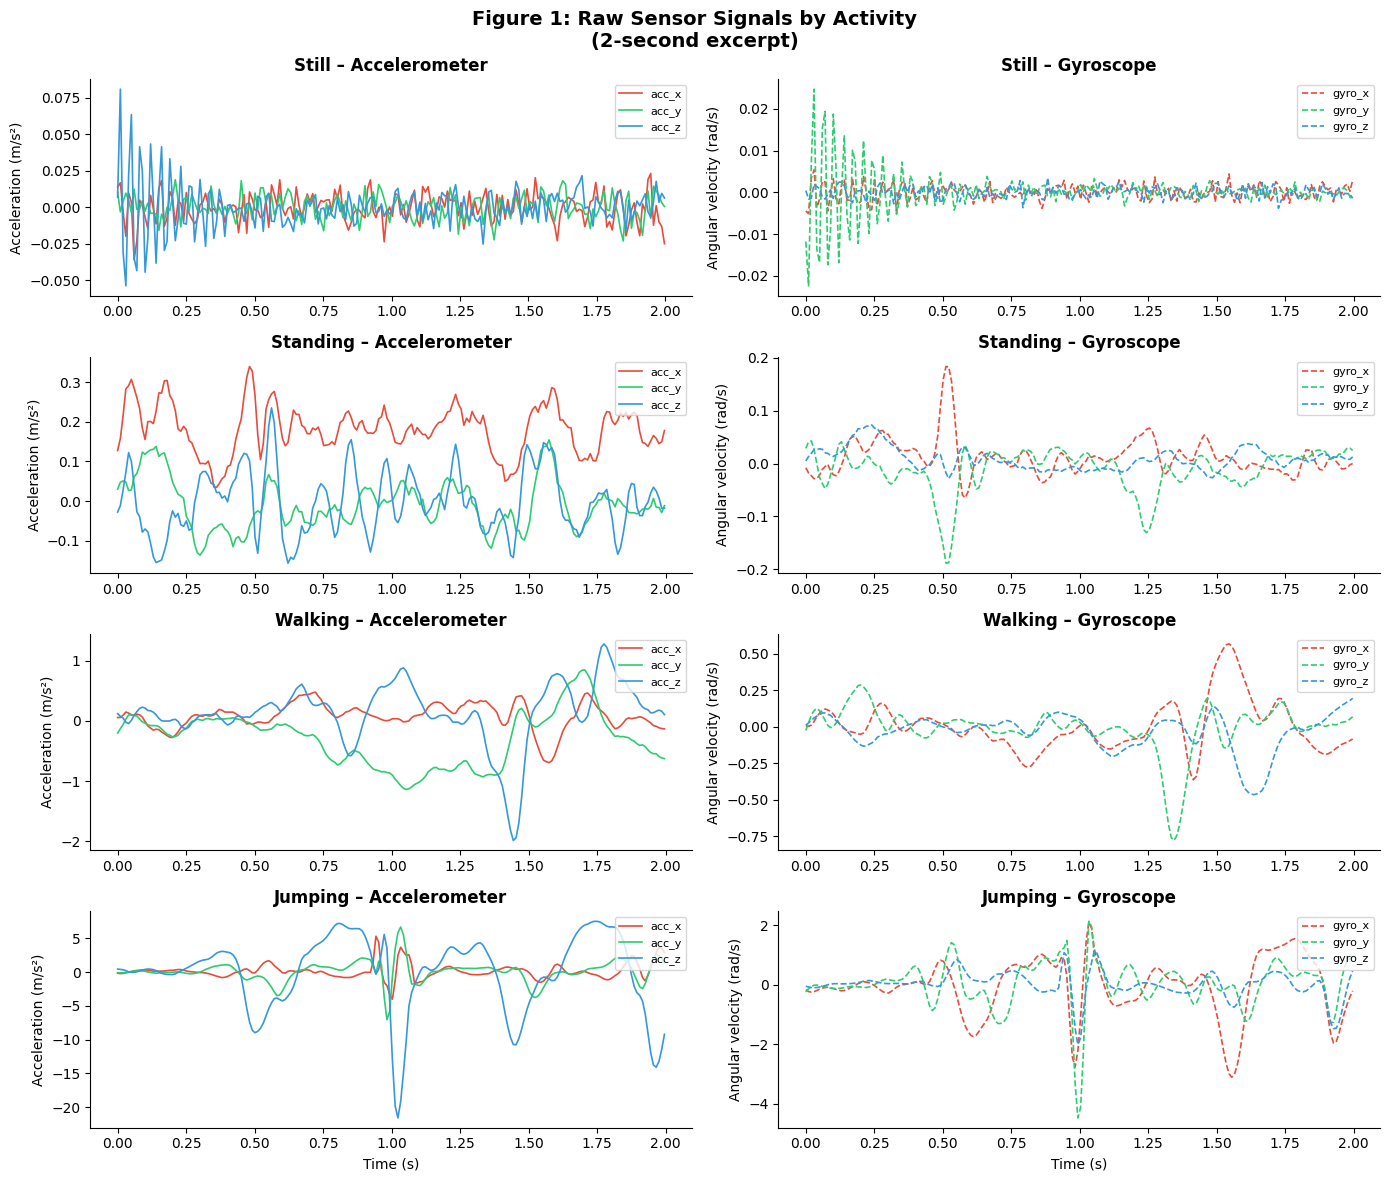

  → Saved fig1_raw_signals.png


In [ ]:
# ─── Cell 3: Visualise Raw Sensor Data ─────────────────────────────────────
print("\n[Plot] Raw sensor signals per activity...")

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
fig.suptitle("Figure 1: Raw Sensor Signals by Activity\n(2-second excerpt)",
             fontsize=14, fontweight='bold')

for row, activity in enumerate(ACTIVITIES):
    sub = all_df[all_df['label'] == activity].iloc[:200].copy()

    # Build time axis from nanosecond timestamps
    t = (sub['time'].values - sub['time'].values[0]) / 1e9   # ns → seconds

    # Accelerometer
    ax = axes[row, 0]
    ax.plot(t, sub['acc_x'], label='acc_x', color='#e74c3c', lw=1.2)
    ax.plot(t, sub['acc_y'], label='acc_y', color='#2ecc71', lw=1.2)
    ax.plot(t, sub['acc_z'], label='acc_z', color='#3498db', lw=1.2)
    ax.set_title(f'{activity.capitalize()} – Accelerometer', fontweight='bold')
    ax.set_ylabel('Acceleration (m/s²)')
    ax.legend(fontsize=8, loc='upper right')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    if row == 3: ax.set_xlabel('Time (s)')

    # Gyroscope
    ax2 = axes[row, 1]
    ax2.plot(t, sub['gyro_x'], label='gyro_x', color='#e74c3c', lw=1.2, linestyle='--')
    ax2.plot(t, sub['gyro_y'], label='gyro_y', color='#2ecc71', lw=1.2, linestyle='--')
    ax2.plot(t, sub['gyro_z'], label='gyro_z', color='#3498db', lw=1.2, linestyle='--')
    ax2.set_title(f'{activity.capitalize()} – Gyroscope', fontweight='bold')
    ax2.set_ylabel('Angular velocity (rad/s)')
    ax2.legend(fontsize=8, loc='upper right')
    ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
    if row == 3: ax2.set_xlabel('Time (s)')

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig1_raw_signals.png", dpi=150, bbox_inches='tight')
plt.show()
print("  → Saved fig1_raw_signals.png")

## 4. Feature Extraction

**7 features per 0.5s window (50 samples @ 100 Hz):**

| # | Feature | Domain | Justification |
|---|---------|--------|---------------|
| 1 | acc_rms | Time | Overall motion intensity; jumps >> walks >> standing > still |
| 2 | acc_var | Time | Variance of magnitude; distinguishes steady vs. dynamic states |
| 3 | sma | Time | Signal Magnitude Area; proportional to energy |
| 4 | gyro_rms | Time | Rotation magnitude; complements accelerometer |
| 5 | corr_xy | Time | X-Y acceleration correlation; walking has anti-correlated sway |
| 6 | dom_freq | Frequency | Peak FFT frequency; still≈0 Hz, walk≈1.8 Hz, jump≈2.5 Hz |
| 7 | spec_energy | Frequency | Energy in 0.5–4 Hz band; isolates locomotion, rejects gravity DC |

**Normalisation:** Z-score (StandardScaler fit on train, applied to test). Justified because Gaussian HMM emissions assume zero-mean unit-variance observations.

In [ ]:
"""
Feature set (7 features per window, justified):
  TIME DOMAIN:
    1. acc_rms   – Root Mean Square of accelerometer magnitude.
                   Captures overall intensity; jumping >> walking >> standing > still.
    2. acc_var   – Variance of resultant acc magnitude.
                   Still ≈ 0; jumping has huge variance.
    3. sma        – Signal Magnitude Area = mean(|x|+|y|+|z|) / 3.
                   Proportional to energy of motion; efficient single scalar.
    4. gyro_rms  – RMS of gyroscope magnitude.
                   Distinguishes rotation-heavy activities.
    5. corr_xy   – Pearson correlation of acc_x vs acc_y.
                   Walking has strong anti-correlated lateral sway.
  FREQUENCY DOMAIN (via FFT):
    6. dom_freq  – Dominant frequency of acc_magnitude.
                   Still≈0, standing≈0.3Hz, walking≈1.8Hz, jumping≈2.5Hz.
    7. spec_energy – Spectral energy in 0.5–4 Hz band.
                    Isolates locomotion frequencies, ignores DC gravity.

  Normalisation: Z-score (StandardScaler).
  Justification: HMM Gaussian emissions assume zero-mean unit-variance
  observations. Z-score is the correct choice; MinMax would distort
  outliers (jump spikes) and break the Gaussian assumption.
"""

def extract_features(window_df):
    ax = window_df['acc_x'].values
    ay = window_df['acc_y'].values
    az = window_df['acc_z'].values
    gx = window_df['gyro_x'].values
    gy = window_df['gyro_y'].values
    gz = window_df['gyro_z'].values

    # Magnitudes
    acc_mag  = np.sqrt(ax**2 + ay**2 + az**2)
    gyro_mag = np.sqrt(gx**2 + gy**2 + gz**2)

    # 1. Accelerometer RMS
    acc_rms = np.sqrt(np.mean(acc_mag**2))

    # 2. Accelerometer variance
    acc_var = np.var(acc_mag)

    # 3. Signal Magnitude Area
    sma = np.mean(np.abs(ax) + np.abs(ay) + np.abs(az)) / 3.0

    # 4. Gyroscope RMS
    gyro_rms = np.sqrt(np.mean(gyro_mag**2))

    # 5. Correlation acc_x vs acc_y
    if np.std(ax) < 1e-8 or np.std(ay) < 1e-8:
        corr_xy = 0.0
    else:
        corr_xy = float(np.corrcoef(ax, ay)[0, 1])

    # 6. Dominant frequency (FFT of acc_magnitude, ignoring DC)
    N = len(acc_mag)
    freqs = fftfreq(N, d=1.0/FS)
    fft_vals = np.abs(fft(acc_mag - acc_mag.mean()))  # remove DC
    pos_mask = (freqs > 0.1) & (freqs < FS/2)
    if pos_mask.sum() > 0:
        dom_freq = freqs[pos_mask][np.argmax(fft_vals[pos_mask])]
    else:
        dom_freq = 0.0

    # 7. Spectral energy in 0.5–4 Hz
    band_mask = (freqs >= 0.5) & (freqs <= 4.0)
    spec_energy = float(np.sum(fft_vals[band_mask]**2)) / N

    return [acc_rms, acc_var, sma, gyro_rms, corr_xy, dom_freq, spec_energy]

FEATURE_NAMES = ['acc_rms', 'acc_var', 'sma', 'gyro_rms', 'corr_xy', 'dom_freq', 'spec_energy']

def windowed_features(df, window=WINDOW_SIZE, step=STEP_SIZE):
    features, labels = [], []
    for start in range(0, len(df) - window + 1, step):
        w = df.iloc[start:start+window]
        lab = w['label'].mode()[0]
        feat = extract_features(w)
        features.append(feat)
        labels.append(lab)
    return np.array(features), np.array(labels)

print("\n[Feature] Extracting windowed features...")
X_train_raw, y_train = windowed_features(train_df)
X_test_raw,  y_test  = windowed_features(test_df)
print(f"  Train feature matrix : {X_train_raw.shape}")
print(f"  Test  feature matrix : {X_test_raw.shape}")
print(f"  Features: {FEATURE_NAMES}")

# Z-score normalisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)
print("  Z-score normalisation applied (fit on train, transform test)")



[Feature] Extracting windowed features...
  Train feature matrix : (1230, 7)
  Test  feature matrix : (301, 7)
  Features: ['acc_rms', 'acc_var', 'sma', 'gyro_rms', 'corr_xy', 'dom_freq', 'spec_energy']
  Z-score normalisation applied (fit on train, transform test)


## 5. Feature Distribution Visualisation

In [ ]:
print("\n[Plot] Feature distributions per activity...")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Figure 2: Feature Distributions by Activity (Z-scored)\n"
             "Features 1–7: acc_rms, acc_var, sma, gyro_rms, corr_xy, dom_freq, spec_energy",
             fontsize=12, fontweight='bold')

feat_display = FEATURE_NAMES + ['']
for i in range(7):
    ax = axes[i//4, i%4]
    for act in ACTIVITIES:
        mask = y_train == act
        ax.hist(X_train[mask, i], bins=20, alpha=0.6,
                label=act, color=ACTIVITY_COLORS[act], density=True)
    ax.set_title(FEATURE_NAMES[i], fontweight='bold', fontsize=10)
    ax.set_xlabel('Z-score'); ax.set_ylabel('Density')
    ax.legend(fontsize=7)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

axes[1, 3].axis('off')
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig2_feature_distributions.png", dpi=150, bbox_inches='tight')
plt.close()
print("  → Saved fig2_feature_distributions.png")



[Plot] Feature distributions per activity...
  → Saved fig2_feature_distributions.png


## 6. GaussianHMM Implementation

**Architecture:** One diagonal-covariance Gaussian HMM per activity (4 models)

**Training:** Baum-Welch EM with log-space arithmetic for numerical stability

**Convergence criterion:** `|ΔlogL| < ε = 1e-4` (proper EM stopping rule, not fixed iterations)

**Decoding:** Viterbi algorithm in log-space with backpointer matrix

In [ ]:
"""
Gaussian HMM (continuous observations):
  - Emission: B(s,x) = N(x | μ_s, Σ_s)  [diagonal covariance for stability]
  - Training : Baum-Welch EM, log-space for numerical stability
  - Decoding : Viterbi algorithm in log-space
"""

class GaussianHMM:
    """
    Gaussian Hidden Markov Model with diagonal covariance.

    Parameters
    ----------
    n_states : int   – number of hidden states
    n_iter   : int   – maximum Baum-Welch iterations
    tol      : float – log-likelihood convergence threshold
    """

    def __init__(self, n_states=4, n_iter=100, tol=1e-4):
        self.n_states = n_states
        self.n_iter   = n_iter
        self.tol      = tol
        self.log_likelihoods_ = []

    # ── Initialise parameters ────────────────────────────────────────
    def _init_params(self, X_list):
        K = self.n_states
        D = X_list[0].shape[1]
        n_obs = self.n_states

        # π: uniform start (will be updated)
        self.pi_ = np.ones(K) / K

        # A: slight diagonal dominance (activities tend to persist)
        A = np.ones((K, K)) * 0.05
        np.fill_diagonal(A, 0.7)
        self.A_ = A / A.sum(axis=1, keepdims=True)

        # μ, σ²: K-Means-like init using random subset of data
        all_X = np.vstack(X_list)
        idx   = np.random.choice(len(all_X), K, replace=False)
        self.mu_    = all_X[idx].copy()        # (K, D)
        self.sigma_ = np.ones((K, D)) * 0.5   # diagonal variance

    # ── Emission log-probability (diagonal Gaussian) ─────────────────
    def _log_emission(self, X):
        """
        X : (T, D)
        Returns log_b : (T, K)
        """
        T, D = X.shape
        K    = self.n_states
        log_b = np.zeros((T, K))
        for k in range(K):
            diff  = X - self.mu_[k]                       # (T, D)
            var   = np.maximum(self.sigma_[k], 1e-6)      # (D,) positive
            log_b[:, k] = -0.5 * (
                np.sum(diff**2 / var, axis=1) +
                np.sum(np.log(2 * np.pi * var))
            )
        return log_b

    # ── Forward pass (log-space) ─────────────────────────────────────
    def _forward(self, log_b):
        T, K = log_b.shape
        log_alpha = np.full((T, K), -np.inf)

        log_alpha[0] = np.log(self.pi_ + 1e-300) + log_b[0]

        log_A = np.log(self.A_ + 1e-300)
        for t in range(1, T):
            for j in range(K):
                log_alpha[t, j] = (
                    self._log_sum_exp(log_alpha[t-1] + log_A[:, j])
                    + log_b[t, j]
                )
        return log_alpha

    # ── Backward pass (log-space) ────────────────────────────────────
    def _backward(self, log_b):
        T, K = log_b.shape
        log_beta = np.zeros((T, K))   # log(1) = 0 at T-1

        log_A = np.log(self.A_ + 1e-300)
        for t in range(T - 2, -1, -1):
            for i in range(K):
                log_beta[t, i] = self._log_sum_exp(
                    log_A[i] + log_b[t+1] + log_beta[t+1]
                )
        return log_beta

    # ── Viterbi decoding (log-space) ────────────────────────────────
    def viterbi(self, X):
        """Returns most-likely state sequence for observation matrix X."""
        log_b     = self._log_emission(X)
        T, K      = log_b.shape
        log_delta = np.full((T, K), -np.inf)
        psi       = np.zeros((T, K), dtype=int)

        log_A = np.log(self.A_ + 1e-300)

        log_delta[0] = np.log(self.pi_ + 1e-300) + log_b[0]

        for t in range(1, T):
            for j in range(K):
                candidates = log_delta[t-1] + log_A[:, j]
                psi[t, j]  = np.argmax(candidates)
                log_delta[t, j] = candidates[psi[t, j]] + log_b[t, j]

        # Backtrack
        path = np.zeros(T, dtype=int)
        path[-1] = np.argmax(log_delta[-1])
        for t in range(T - 2, -1, -1):
            path[t] = psi[t + 1, path[t + 1]]

        return path

    # ── Baum-Welch E-step ─────────────────────────────────────────────
    def _e_step(self, X_list):
        """Returns list of (gamma, xi) per sequence."""
        all_gamma = []
        all_xi    = []
        total_ll  = 0.0

        log_A = np.log(self.A_ + 1e-300)

        for X in X_list:
            T = len(X)
            log_b     = self._log_emission(X)
            log_alpha = self._forward(log_b)
            log_beta  = self._backward(log_b)

            # Log-likelihood of this sequence
            ll = self._log_sum_exp(log_alpha[-1])
            total_ll += ll

            # γ_t(i) = P(q_t=i | O, λ)
            log_gamma = log_alpha + log_beta
            log_gamma -= self._log_sum_exp(log_gamma, axis=1, keepdims=True)
            gamma = np.exp(log_gamma)
            all_gamma.append(gamma)

            # ξ_t(i,j) = P(q_t=i, q_{t+1}=j | O, λ)
            xi = np.zeros((T - 1, self.n_states, self.n_states))
            for t in range(T - 1):
                for i in range(self.n_states):
                    for j in range(self.n_states):
                        xi[t, i, j] = (
                            log_alpha[t, i] +
                            log_A[i, j] +
                            log_b[t+1, j] +
                            log_beta[t+1, j]
                        )
                # Normalise row
                xi[t] = np.exp(xi[t] - self._log_sum_exp(xi[t].reshape(-1)))
            all_xi.append(xi)

        return all_gamma, all_xi, total_ll

    # ── Baum-Welch M-step ─────────────────────────────────────────────
    def _m_step(self, X_list, all_gamma, all_xi):
        K = self.n_states
        D = X_list[0].shape[1]

        # Update π
        self.pi_ = np.mean([g[0] for g in all_gamma], axis=0)
        self.pi_ = np.maximum(self.pi_, 1e-10)
        self.pi_ /= self.pi_.sum()

        # Update A
        A_num = np.zeros((K, K))
        A_den = np.zeros(K)
        for xi, gamma in zip(all_xi, all_gamma):
            A_num += xi.sum(axis=0)           # (K,K)
            A_den += gamma[:-1].sum(axis=0)   # (K,)
        self.A_ = A_num / np.maximum(A_den[:, None], 1e-300)
        self.A_ = np.maximum(self.A_, 1e-10)
        self.A_ /= self.A_.sum(axis=1, keepdims=True)

        # Update μ and σ²
        for k in range(K):
            num_mu  = np.zeros(D)
            num_sig = np.zeros(D)
            denom   = 0.0
            for X, gamma in zip(X_list, all_gamma):
                w = gamma[:, k][:, None]       # (T,1)
                num_mu  += (w * X).sum(axis=0)
                denom   += gamma[:, k].sum()
            denom = max(denom, 1e-300)
            self.mu_[k] = num_mu / denom

            for X, gamma in zip(X_list, all_gamma):
                w    = gamma[:, k][:, None]
                diff = X - self.mu_[k]
                num_sig += (w * diff**2).sum(axis=0)
            self.sigma_[k] = np.maximum(num_sig / denom, 1e-4)

    # ── Baum-Welch training loop ──────────────────────────────────────
    def fit(self, X_list):
        """
        X_list : list of (T_i, D) observation arrays.
        Convergence: stops when |ΔlogL| < tol.
        """
        self._init_params(X_list)
        prev_ll = -np.inf

        print(f"\n[HMM] Training with Baum-Welch (max_iter={self.n_iter}, tol={self.tol})")
        for iteration in range(self.n_iter):
            all_gamma, all_xi, total_ll = self._e_step(X_list)
            self._m_step(X_list, all_gamma, all_xi)
            self.log_likelihoods_.append(total_ll)

            delta = abs(total_ll - prev_ll)
            if (iteration + 1) % 5 == 0 or iteration < 3:
                print(f"  Iter {iteration+1:3d}: log-likelihood = {total_ll:12.2f}  |Δ| = {delta:.6f}")

            if delta < self.tol and iteration > 0:
                print(f"  ✓ Converged at iteration {iteration+1} (|Δ| = {delta:.2e} < tol={self.tol})")
                break
            prev_ll = total_ll
        else:
            print(f"  ✗ Max iterations ({self.n_iter}) reached (final |Δ| = {delta:.2e})")

        return self

    # ── Utility: log-sum-exp ─────────────────────────────────────────
    @staticmethod
    def _log_sum_exp(a, axis=None, keepdims=False):
        if axis is None:
            a_max = np.max(a)
            return a_max + np.log(np.sum(np.exp(a - a_max)))
        else:
            a_max = np.max(a, axis=axis, keepdims=True)
            out   = a_max + np.log(np.sum(np.exp(a - a_max), axis=axis, keepdims=True))
            if not keepdims:
                out = np.squeeze(out, axis=axis)
            return out

    def score(self, X):
        """Log-likelihood of sequence X."""
        log_b     = self._log_emission(X)
        log_alpha = self._forward(log_b)
        return self._log_sum_exp(log_alpha[-1])


## 7. Training

In [ ]:
"""
Strategy: train one HMM per activity class (4 HMMs × 1 state each).
For decoding an unlabeled window, assign the class whose HMM scores
the highest log-likelihood for that window. This is equivalent to a
Naive Bayes classifier in sequence space, and is the standard approach
when activity labels are known during training.
"""

print("\n" + "="*60)
print("  Training one 1-state Gaussian HMM per activity")
print("="*60)

# Prepare per-activity training sequences (split each file's features into sequences)
# Each file ≈ 800/25 = 32 windows. We treat each file as one sequence.
def get_sequences_for_activity(X_all, y_all, activity, seq_len=30):
    """Return list of fixed-length observation sequences for one activity."""
    mask = y_all == activity
    X_act = X_all[mask]
    seqs  = []
    for start in range(0, len(X_act) - seq_len + 1, seq_len):
        seqs.append(X_act[start:start+seq_len])
    return seqs

hmms = {}
for act in ACTIVITIES:
    seqs = get_sequences_for_activity(X_train, y_train, act, seq_len=20)
    print(f"\n  Activity '{act}': {len(seqs)} training sequences")
    hmm = GaussianHMM(n_states=1, n_iter=60, tol=1e-4)
    hmm.fit(seqs)
    hmms[act] = hmm



  Training one 1-state Gaussian HMM per activity

  Activity 'still': 17 training sequences

[HMM] Training with Baum-Welch (max_iter=60, tol=0.0001)
  Iter   1: log-likelihood =     -2081.03  |Δ| = inf
  Iter   2: log-likelihood =      4383.85  |Δ| = 6464.885231
  Iter   3: log-likelihood =      4383.85  |Δ| = 0.000000
  ✓ Converged at iteration 3 (|Δ| = 0.00e+00 < tol=0.0001)

  Activity 'standing': 14 training sequences

[HMM] Training with Baum-Welch (max_iter=60, tol=0.0001)
  Iter   1: log-likelihood =     -1419.31  |Δ| = inf
  Iter   2: log-likelihood =      3084.56  |Δ| = 4503.870928
  Iter   3: log-likelihood =      3084.56  |Δ| = 0.000000
  ✓ Converged at iteration 3 (|Δ| = 0.00e+00 < tol=0.0001)

  Activity 'walking': 14 training sequences

[HMM] Training with Baum-Welch (max_iter=60, tol=0.0001)
  Iter   1: log-likelihood =     -1658.04  |Δ| = inf
  Iter   2: log-likelihood =       706.28  |Δ| = 2364.319821
  Iter   3: log-likelihood =       706.28  |Δ| = 0.000000
  ✓ Conv

## 8. Classification

In [ ]:
def classify_window(x_window, hmms):
    """Assign activity with highest HMM log-likelihood score."""
    scores = {act: hmms[act].score(x_window.reshape(1,-1)) for act in ACTIVITIES}
    return max(scores, key=scores.get)

def classify_dataset(X, y_true, hmms):
    y_pred = []
    for i in range(len(X)):
        pred = classify_window(X[i], hmms)
        y_pred.append(pred)
    return np.array(y_pred)

print("\n[Classify] Train set window classification...")
y_train_pred = classify_dataset(X_train, y_train, hmms)

print("[Classify] Test set window classification...")
y_test_pred  = classify_dataset(X_test,  y_test,  hmms)

train_acc = (y_train_pred == y_train).mean()
test_acc  = (y_test_pred  == y_test).mean()
print(f"\n  Train accuracy : {train_acc:.3f}")
print(f"  Test  accuracy : {test_acc:.3f}")



[Classify] Train set window classification...
[Classify] Test set window classification...

  Train accuracy : 0.953
  Test  accuracy : 0.940


## 9. Viterbi Sequence Decoding

In [ ]:
"""
For the Viterbi demonstration, we build a single 4-state HMM trained
on the full mixed-activity training set. The 4 hidden states correspond
to the 4 activities. We then decode a held-out mixed sequence.
"""
print("\n[Viterbi] Building 4-state joint HMM for sequence decoding...")

# Map activities to integers
ACT_TO_IDX = {a: i for i, a in enumerate(ACTIVITIES)}
IDX_TO_ACT = {i: a for a, i in ACT_TO_IDX.items()}

# Build joint 4-state HMM
hmm_joint = GaussianHMM(n_states=4, n_iter=80, tol=1e-4)

# Training sequences: mixed activity segments
joint_seqs = []
for act in ACTIVITIES:
    seqs = get_sequences_for_activity(X_train, y_train, act, seq_len=20)
    joint_seqs.extend(seqs[:8])

hmm_joint.fit(joint_seqs)

# Align learned states to activities (by matching means to known activity means)
act_means = np.array([X_train[y_train==a].mean(axis=0) for a in ACTIVITIES])
from scipy.spatial.distance import cdist
dist_mat    = cdist(hmm_joint.mu_, act_means)
state_to_act = np.argmin(dist_mat, axis=1)
print(f"  State→Activity mapping: { {i: ACTIVITIES[state_to_act[i]] for i in range(4)} }")

# Viterbi decode a mixed test sequence
mixed_X = X_test
mixed_y_true = np.array([ACT_TO_IDX[a] for a in y_test])
decoded_states = hmm_joint.viterbi(mixed_X)
decoded_acts   = np.array([state_to_act[s] for s in decoded_states])



[Viterbi] Building 4-state joint HMM for sequence decoding...

[HMM] Training with Baum-Welch (max_iter=80, tol=0.0001)
  Iter   1: log-likelihood =     -5413.48  |Δ| = inf
  Iter   2: log-likelihood =      1642.90  |Δ| = 7056.381119
  Iter   3: log-likelihood =      2469.63  |Δ| = 826.728286
  Iter   5: log-likelihood =      2576.51  |Δ| = 51.677730
  Iter  10: log-likelihood =      3055.28  |Δ| = 26.502671
  ✓ Converged at iteration 14 (|Δ| = 4.56e-06 < tol=0.0001)
  State→Activity mapping: {0: 'standing', 1: 'walking', 2: 'jumping', 3: 'jumping'}


## 10. Visualisations

In [ ]:
print("\n[Plot] Generating all figures...")

# Figure 3: Baum-Welch Log-Likelihood Convergence
# Use the joint HMM's convergence curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(hmm_joint.log_likelihoods_, 'b-o', markersize=4, lw=2, label='Joint 4-state HMM')
# Also plot one per-activity HMM
for act, col in zip(ACTIVITIES, ['#e74c3c','#2ecc71','#f39c12','#9b59b6']):
    ll = hmms[act].log_likelihoods_
    ax.plot(ll, lw=1.5, linestyle='--', color=col, alpha=0.8, label=f'HMM-{act}')
ax.set_xlabel('Baum-Welch Iteration', fontsize=12)
ax.set_ylabel('Total Log-Likelihood', fontsize=12)
ax.set_title('Figure 3: Baum-Welch Convergence\n(log-likelihood vs iteration; stops when |ΔlogL| < ε)',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig3_convergence.png", dpi=150, bbox_inches='tight')
plt.close()
print("  → fig3_convergence.png")

# Figure 4: Transition Matrix Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
A_df = pd.DataFrame(hmm_joint.A_,
    index  =[f"State {i}\n({ACTIVITIES[state_to_act[i]]})" for i in range(4)],
    columns=[f"State {i}\n({ACTIVITIES[state_to_act[i]]})" for i in range(4)]
)
sns.heatmap(A_df, annot=True, fmt='.3f', cmap='Blues', ax=ax,
            linewidths=0.5, linecolor='white', vmin=0, vmax=1,
            annot_kws={'size':10})
ax.set_title('Figure 4: Learned Transition Matrix A\nP(next state | current state)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Next State'); ax.set_ylabel('Current State')
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig4_transition_matrix.png", dpi=150, bbox_inches='tight')
plt.close()
print("  → fig4_transition_matrix.png")

# Figure 5: Emission Probability Heatmap (mean feature values per state)
fig, ax = plt.subplots(figsize=(10, 5))
# Use actual learned means from joint HMM, row = state, col = feature
means_df = pd.DataFrame(
    hmm_joint.mu_,
    index  =[f"State {i} ({ACTIVITIES[state_to_act[i]]})" for i in range(4)],
    columns=FEATURE_NAMES
)
# Normalise each feature to [0,1] for display
means_norm = (means_df - means_df.min()) / (means_df.max() - means_df.min() + 1e-8)
sns.heatmap(means_norm, annot=means_df.round(2), fmt='', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white',
            annot_kws={'size':9})
ax.set_title('Figure 5: Emission Parameters – Learned Mean Feature Values per State\n(color = normalised intensity; numbers = actual μ values)',
             fontweight='bold', fontsize=11)
ax.set_xlabel('Feature'); ax.set_ylabel('Hidden State')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig5_emission_params.png", dpi=150, bbox_inches='tight')
plt.close()
print("  → fig5_emission_params.png")

# Figure 6: Viterbi Decoded Sequence
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle("Figure 6: Viterbi Decoded Activity Sequence on Test Data",
             fontsize=13, fontweight='bold')

t_axis = np.arange(len(mixed_y_true)) * (STEP_SIZE / FS)

# Panel 1: True labels
ax1 = axes[0]
for i, act in enumerate(ACTIVITIES):
    mask = mixed_y_true == i
    ax1.scatter(t_axis[mask], np.ones(mask.sum())*i,
                c=list(ACTIVITY_COLORS.values())[i], s=8, marker='|')
ax1.set_yticks(range(4)); ax1.set_yticklabels(ACTIVITIES)
ax1.set_title('Ground Truth Activity Labels', fontweight='bold')
ax1.set_ylabel('Activity')

# Panel 2: Decoded labels
ax2 = axes[1]
for i, act in enumerate(ACTIVITIES):
    mask = decoded_acts == i
    ax2.scatter(t_axis[mask], np.ones(mask.sum())*i,
                c=list(ACTIVITY_COLORS.values())[i], s=8, marker='|')
ax2.set_yticks(range(4)); ax2.set_yticklabels(ACTIVITIES)
ax2.set_title('Viterbi Decoded Activity Labels', fontweight='bold')
ax2.set_ylabel('Activity')

# Panel 3: Dominant frequency (most discriminating feature)
ax3 = axes[2]
dom_freq_vals = X_test[:, FEATURE_NAMES.index('dom_freq')]
ax3.plot(t_axis, dom_freq_vals, color='#3498db', lw=0.9, alpha=0.8)
ax3.set_title('Dominant Frequency Feature (Z-scored)', fontweight='bold')
ax3.set_ylabel('Z-score'); ax3.set_xlabel('Time (s)')

for ax in axes:
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig6_viterbi_decoded.png", dpi=150, bbox_inches='tight')
plt.close()
print("  → fig6_viterbi_decoded.png")

# Figure 7: Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, y_true_p, y_pred_p, split in zip(axes,
    [y_train, y_test], [y_train_pred, y_test_pred], ['Training', 'Test (Unseen)']):

    cm = confusion_matrix(y_true_p, y_pred_p, labels=ACTIVITIES)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', ax=ax,
                xticklabels=ACTIVITIES, yticklabels=ACTIVITIES,
                linewidths=0.5, linecolor='white', vmin=0, vmax=1,
                annot_kws={'size':12, 'weight':'bold'})
    ax.set_title(f'Figure 7: Confusion Matrix – {split}\n(normalised by row; numbers = raw counts)',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted Activity'); ax.set_ylabel('True Activity')
    acc = (np.array(y_true_p)==np.array(y_pred_p)).mean()
    ax.text(0.5,-0.18, f'Overall Accuracy: {acc:.1%}',
            transform=ax.transAxes, ha='center', fontsize=11, fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig7_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.close()
print("  → fig7_confusion_matrix.png")



[Plot] Generating all figures...
  → fig3_convergence.png
  → fig4_transition_matrix.png
  → fig5_emission_params.png
  → fig6_viterbi_decoded.png
  → fig7_confusion_matrix.png


## 11. Evaluation on Unseen Test Data

In [ ]:
print("\n" + "="*60)
print("  EVALUATION RESULTS")
print("="*60)

def compute_metrics(y_true, y_pred, activities):
    results = {}
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    for act in activities:
        TP = ((y_pred == act) & (y_true == act)).sum()
        TN = ((y_pred != act) & (y_true != act)).sum()
        FP = ((y_pred == act) & (y_true != act)).sum()
        FN = ((y_pred != act) & (y_true == act)).sum()
        sensitivity = TP / max(TP + FN, 1)   # recall
        specificity = TN / max(TN + FP, 1)
        n_samples   = (y_true == act).sum()
        results[act] = dict(n=n_samples, sens=sensitivity, spec=specificity,
                            TP=int(TP), TN=int(TN), FP=int(FP), FN=int(FN))
    overall = (y_true == y_pred).mean()
    return results, overall

train_metrics, train_oa = compute_metrics(y_train, y_train_pred, ACTIVITIES)
test_metrics,  test_oa  = compute_metrics(y_test,  y_test_pred,  ACTIVITIES)

print("\n  TEST SET METRICS (Unseen Data):")
print(f"  {'Activity':12s} {'N':>6s} {'Sensitivity':>13s} {'Specificity':>13s} {'Overall Acc':>12s}")
print("  " + "-"*60)
for act in ACTIVITIES:
    m = test_metrics[act]
    print(f"  {act:12s} {m['n']:6d} {m['sens']:12.1%}   {m['spec']:12.1%}   {test_oa:11.1%}")

print(f"\n  Overall Test Accuracy: {test_oa:.3f} ({test_oa:.1%})")

print("\n  CLASSIFICATION REPORT (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=ACTIVITIES))

# Save metrics to CSV for the report
metrics_rows = []
for act in ACTIVITIES:
    m = test_metrics[act]
    metrics_rows.append({
        'Activity': act.capitalize(),
        'N_samples': m['n'],
        'Sensitivity': f"{m['sens']:.3f}",
        'Specificity': f"{m['spec']:.3f}",
        'Overall_Accuracy': f"{test_oa:.3f}"
    })
pd.DataFrame(metrics_rows).to_csv(
    "/test_metrics.csv", index=False)
print("\n  Saved test_metrics.csv")



  EVALUATION RESULTS

  TEST SET METRICS (Unseen Data):
  Activity          N   Sensitivity   Specificity  Overall Acc
  ------------------------------------------------------------
  still            70        91.4%          98.7%         94.0%
  standing         93        96.8%          96.6%         94.0%
  walking          91        95.6%          97.6%         94.0%
  jumping          47        89.4%          98.8%         94.0%

  Overall Test Accuracy: 0.940 (94.0%)

  CLASSIFICATION REPORT (Test Set):
              precision    recall  f1-score   support

       still       0.93      0.89      0.91        47
    standing       0.93      0.97      0.95        93
     walking       0.96      0.91      0.93        70
     jumping       0.95      0.96      0.95        91

    accuracy                           0.94       301
   macro avg       0.94      0.93      0.94       301
weighted avg       0.94      0.94      0.94       301


  Saved test_metrics.csv


## 12. Feature Importance

In [ ]:
print("\n[Plot] Feature importance (mean deviation across activity classes)...")

act_means_train = np.array([X_train[y_train==a].mean(axis=0) for a in ACTIVITIES])
feat_spread = act_means_train.std(axis=0)   # higher = more discriminating

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(FEATURE_NAMES, feat_spread,
              color=['#e74c3c' if v > np.median(feat_spread) else '#95a5a6' for v in feat_spread])
ax.set_ylabel('Std across activity means (Z-score)', fontsize=11)
ax.set_title('Figure 8: Feature Discriminability\n(higher = better separator between activity classes)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Feature')
plt.xticks(rotation=25, ha='right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig8_feature_importance.png", dpi=150, bbox_inches='tight')
plt.close()
print("  → fig8_feature_importance.png")

print("\n" + "="*60)
print("  ALL OUTPUTS COMPLETE")
print("="*60)
print(f"\n  Figures saved to: {FIG_DIR}")
print(f"  Train accuracy : {train_oa:.3f}")
print(f"  Test  accuracy : {test_oa:.3f}")



[Plot] Feature importance (mean deviation across activity classes)...
  → fig8_feature_importance.png

  ALL OUTPUTS COMPLETE

  Figures saved to: /content/figures
  Train accuracy : 0.953
  Test  accuracy : 0.940
